# Завдання 1: Global YouTube Statistics 2023
1. Прочитайте CSV файл

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df_yt = pd.read_csv('Global YouTube Statistics.csv', encoding='unicode_escape')


2. Виводжу перші п'ять рядків

In [ ]:
print(df_yt.head())

   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...                     2000000.0   
1           US  

3. Виводжу розміри датасету, перевіряю наявність пропусків, дублікатів

In [ ]:
print(f"Розмір: {df_yt.shape}")
print(f"Пропуски:\n{df_yt.isnull().sum()}")
print(f"Дублікати: {df_yt.duplicated().sum()}")

Розмір: (995, 28)
Пропуски:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month                   

4. Є пропуски, замінюю тип даних на float і середнє значення за стовпцем

In [ ]:
numeric_cols = df_yt.select_dtypes(include=['number']).columns
for col in numeric_cols:
    if df_yt[col].isnull().any():
        df_yt[col] = df_yt[col].astype(float)
        df_yt[col] = df_yt[col].fillna(df_yt[col].mean())

5. Ще раз перевіряю кількість пропусків

In [ ]:
print(f"Пропуски після обробки:\n{df_yt.isnull().sum().sum()}")

Пропуски після обробки:
325


6. Перевіряю, скільки унікальних країн представлено у колонці 'Country'

In [ ]:
unique_countries = df_yt['Country'].nunique()
print(f"Кількість унікальних країн: {unique_countries}")

Кількість унікальних країн: 49


7. Будую діаграму розподілу переглядів (kind='hist')

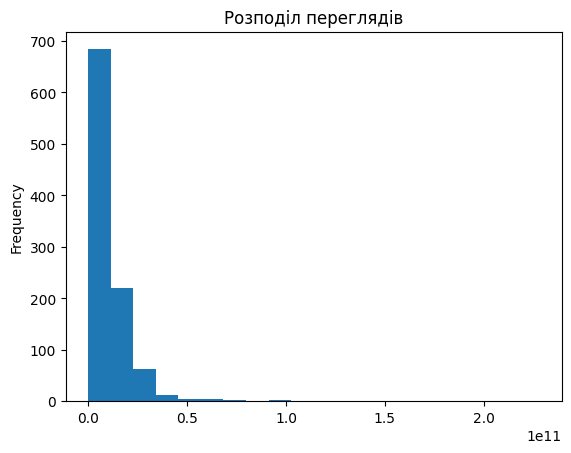

In [ ]:
df_yt['video views'].plot(kind='hist', bins=20, title='Розподіл переглядів')
plt.show()

8. Визначаю максимальну, мінімальну, середню кількість переглядів

In [ ]:
print(f"Max переглядів: {df_yt['video views'].max()}")
print(f"Min переглядів: {df_yt['video views'].min()}")
print(f"Середнє переглядів: {df_yt['video views'].mean()}")

Max переглядів: 228000000000.0
Min переглядів: 0.0
Середнє переглядів: 11039537052.03819


9. Знаходжу країну, де найбільше відео було завантажено на YouTube

In [ ]:
country_most_uploads = df_yt.groupby('Country')['uploads'].sum().idxmax()
print(f"Країна з найбільшою кількістю завантажень: {country_most_uploads}")

Країна з найбільшою кількістю завантажень: India


10. Знажоджу відео з найбільшою та найменшою кількістю завантажень uploads

In [ ]:
max_uploads_video = df_yt.loc[df_yt['uploads'].idxmax(), 'Title']
min_uploads_video = df_yt.loc[df_yt['uploads'].idxmin(), 'Title']
print(f"Відео з max завантажень: {max_uploads_video}")
print(f"Відео з min завантажень: {min_uploads_video}")

Відео з max завантажень: ABP NEWS
Відео з min завантажень: Music


#Завдання 2: Customer Shopping Trends Dataset
Зчитати файл shopping_trends.csv

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_shop = pd.read_csv('shopping_trends.csv')

Перевіряю розмір, наявність пропусків, тип стовпців

In [ ]:
print(df_shop.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

Перейменовую назви стовпців (маленькі букви та підкреслення)

In [ ]:
df_shop.columns = [col.lower().replace(' ', '_') for col in df_shop.columns]

1. Гістограма віку (age) через Seaborn

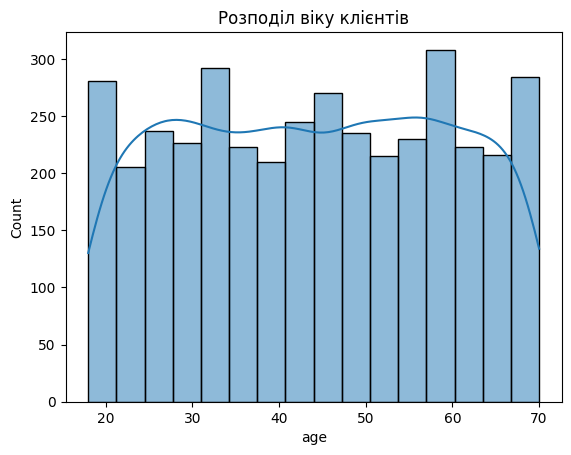

In [ ]:
sns.histplot(df_shop['age'], kde=True)
plt.title('Розподіл віку клієнтів')
plt.show()

2-3. Порівнюю розподіл покупок за статтею (товаром)

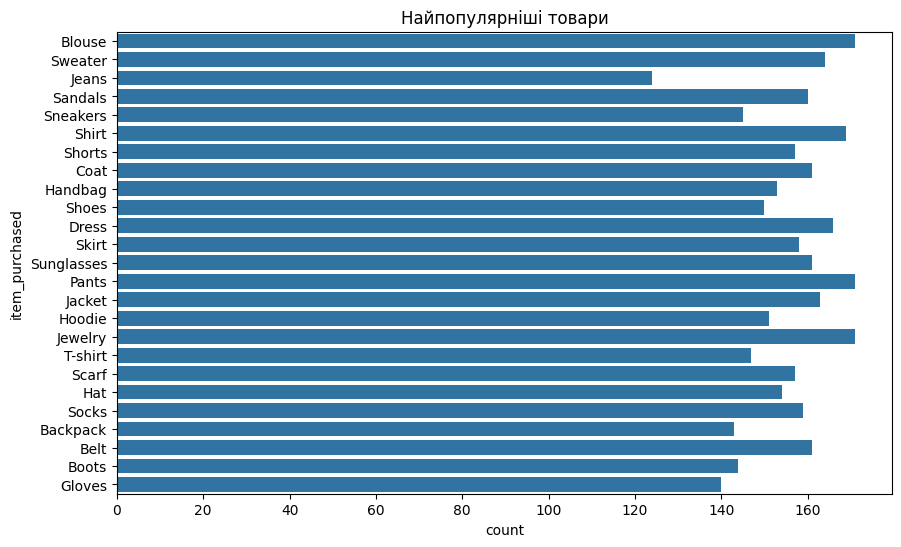

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_shop, y='item_purchased')
plt.title('Найпопулярніші товари')
plt.show()

4-5. Залежність між віком та сумою покупок (scatter plot)

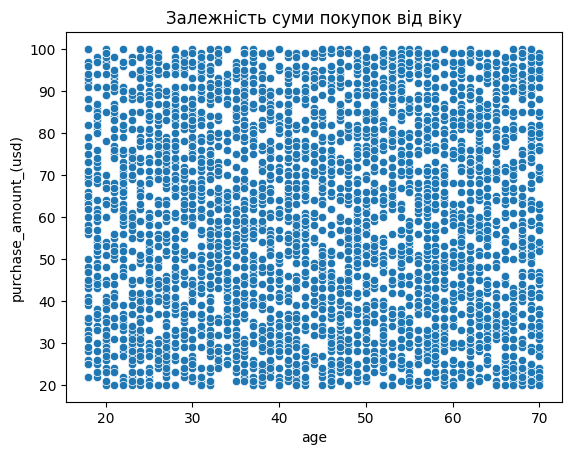

In [ ]:
sns.scatterplot(data=df_shop, x='age', y='purchase_amount_(usd)')
plt.title('Залежність суми покупок від віку')
plt.show()

6-7. Графік розподілу оцінок товарів (review_rating)

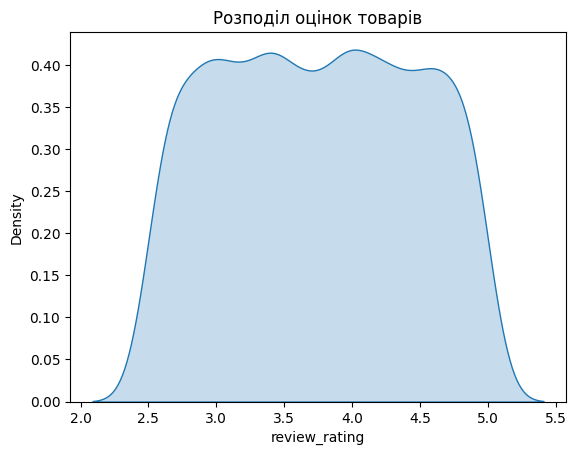

In [ ]:
sns.kdeplot(df_shop['review_rating'], fill=True)
plt.title('Розподіл оцінок товарів')
plt.show()

8-9. Категоріальна діаграма для статі (розподіл покупок)

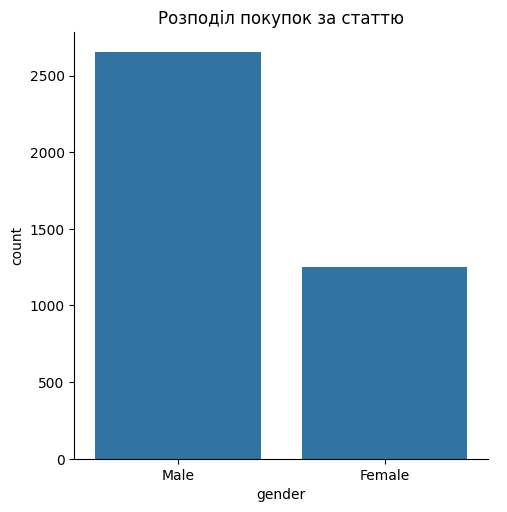

In [ ]:
sns.catplot(data=df_shop, x='gender', kind='count')
plt.title('Розподіл покупок за статтю')
plt.show()

10. Залежність між рейтингом і сумою покупок

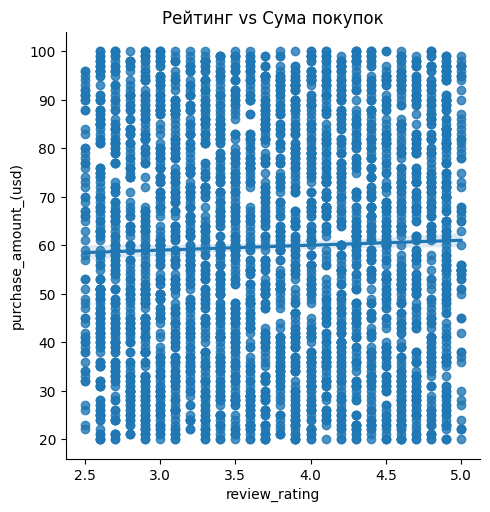

In [ ]:
sns.lmplot(data=df_shop, x='review_rating', y='purchase_amount_(usd)')
plt.title('Рейтинг vs Сума покупок')
plt.show()

# Завдання 3: Візуалізація Altair та Plotly

In [ ]:
import altair as alt
from vega_datasets import data
import plotly.express as px

1.Горизонтальна діаграма врожайності пшениці (Altair)

In [ ]:
wheat = data.wheat()
chart1 = alt.Chart(wheat).mark_bar().encode(
    x='yield:Q',
    y='year:O'
)
text = chart1.mark_text(align='left', baseline='middle', dx=3).encode(
    text='yield:Q'
)
(chart1 + text).display()

alt.LayerChart(...)

2.Багатошарова діаграма електроенергії в Айові (Altair)

In [ ]:
iowa = data.iowa_electricity()
alt.Chart(iowa).mark_area(opacity=0.7).encode(
    x='year:T',
    y='net_generation:Q',
    color='source:N'
).display()

alt.Chart(...)

3.Scatter plot для ірисів (Plotly)

In [ ]:
df_iris = px.data.iris()
fig = px.scatter(df_iris,
                 x='sepal_width',
                 y='sepal_length',
                 size='petal_length',
                 color='species',
                 hover_data=['petal_width'],
                 title='Iris Dataset Analysis')
fig.show()